# Sesi 06 - Analisis Dataset Kaggle Superstore

Menganalisis data penjualan toko retail menggunakan dataset dari Kaggle
Tujuan: menemukan insight bisnis dari data penjualan

## 1. Load & Eksplorasi Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("samplesuperstore.csv", encoding="latin1")

In [7]:
print("Shape: ", df.shape)
print("\n5 baris pertama: ")
df.head()

Shape:  (10194, 21)

5 baris pertama: 


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [13]:
print("Kolom: ", df.columns.tolist())
print("\nTipe Data: ")
print(df.dtypes)
print("\nMissing values: ")
print(df.isnull().sum())

Kolom:  ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Tipe Data: 
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

Missing values: 
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Custo

## 2. Analisis Penjualan per Kategori & Region

In [15]:
# Sales & profit per Kategori
per_kategori = df.groupby("Category").agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum"),
    jumlah_order = ("Order ID", "count")
).reset_index()

print(per_kategori)

          Category  total_sales  total_profit  jumlah_order
0        Furniture  754747.7613    19729.9956          2201
1  Office Supplies  731893.3140   126023.4434          6128
2       Technology  839893.2790   146543.3756          1865


In [17]:
# Sales & profit per Region
per_region = df.groupby("Region").agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum")
).reset_index()

print(per_region)

    Region  total_sales  total_profit
0  Central  503170.6728    39865.3070
1     East  691828.1680    94883.2603
2    South  391721.9050    46749.4303
3     West  739813.6085   110798.8170


## 3. Visualisasi

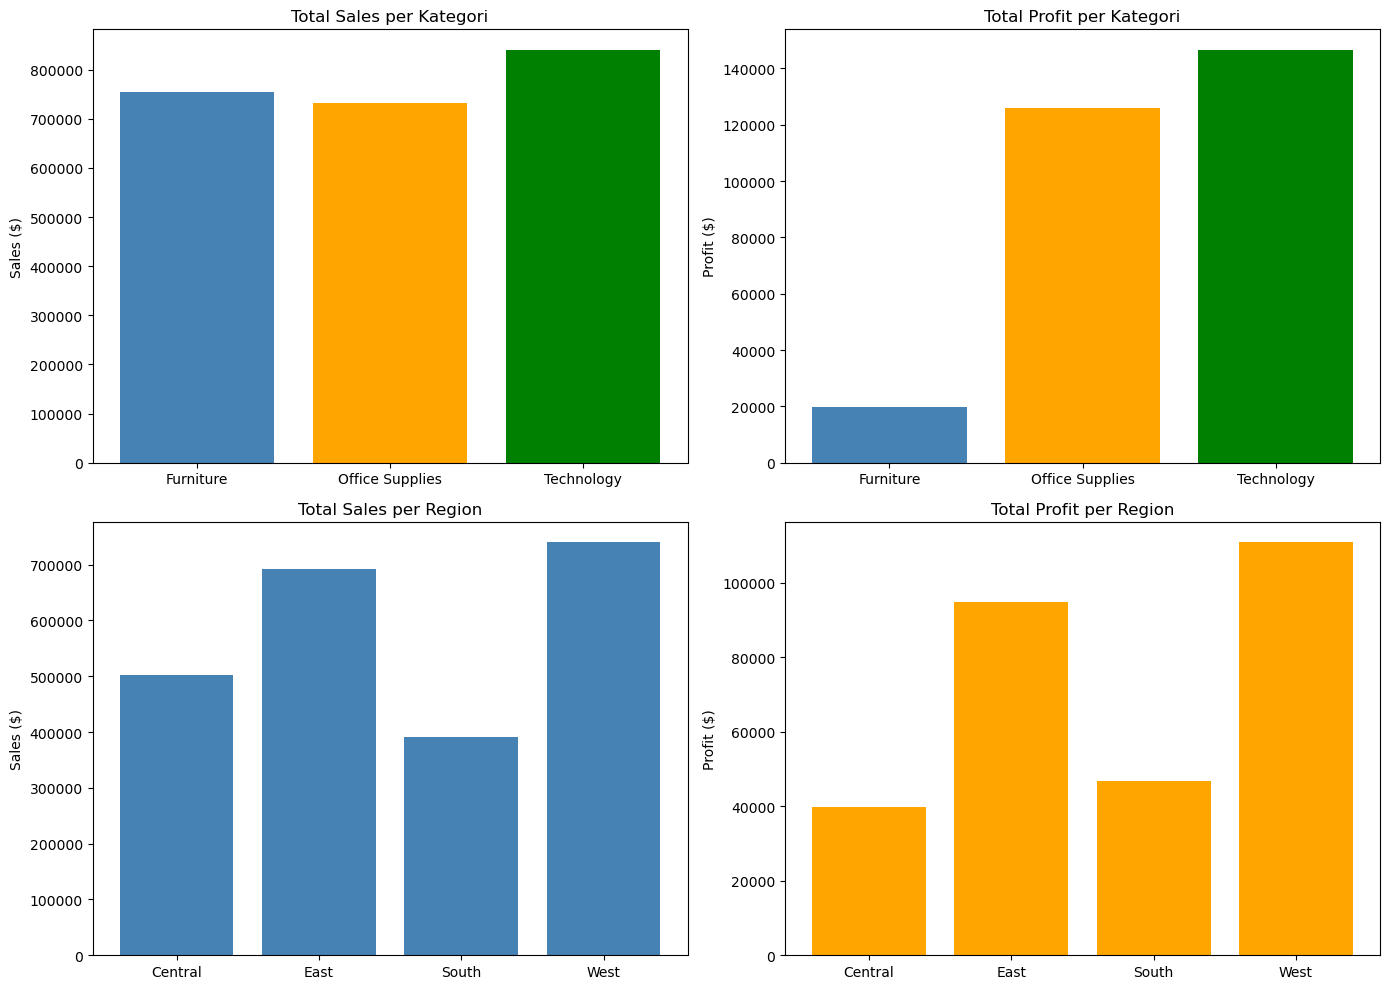

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Sales per Kategori
axes[0,0].bar(per_kategori["Category"], per_kategori["total_sales"], color=["steelblue","orange","green"])
axes[0,0].set_title("Total Sales per Kategori")
axes[0,0].set_ylabel("Sales ($)")

# Chart 2 — Profit per Kategori
axes[0,1].bar(per_kategori["Category"], per_kategori["total_profit"], color=["steelblue","orange","green"])
axes[0,1].set_title("Total Profit per Kategori")
axes[0,1].set_ylabel("Profit ($)")

# Chart 3 — Sales per Region
axes[1,0].bar(per_region["Region"], per_region["total_sales"], color="steelblue")
axes[1,0].set_title("Total Sales per Region")
axes[1,0].set_ylabel("Sales ($)")

# Chart 4 — Profit per Region
axes[1,1].bar(per_region["Region"], per_region["total_profit"], color="orange")
axes[1,1].set_title("Total Profit per Region")
axes[1,1].set_ylabel("Profit ($)")

plt.tight_layout()
plt.show()

## 4. Kesimpulan & Insight Bisnis

In [29]:
print("=" * 60)
print("            INSIGHT BISNIS - SUPERSTORE SALES")
print("=" * 60)

print("\n📦 PER KATEGORI:")
for _, row in per_kategori.iterrows():
    margin = (row['total_profit'] / row['total_sales']) * 100
    print(f"  {row['Category']}")
    print(f"  Sales: ${row['total_sales']:,.0f} | Profit: ${row['total_profit']:,.0f} | Margin: {margin:.1f}%")

print("\n🗺️ PER REGION:")
for _, row in per_region.iterrows():
    margin = (row['total_profit'] / row['total_sales']) * 100
    print(f"  {row['Region']}: Sales ${row['total_sales']:,.0f} | Margin: {margin:.1f}%")

print("\n💡 REKOMENDASI:")
print("  - Focus pada Technology: margin profit tertinggi")
print("  - Evaluasi Furniture: sales tinggi tapi profit rendah")
print("  - Tingkatkan strategi di region South")
print("=" * 60)

            INSIGHT BISNIS - SUPERSTORE SALES

📦 PER KATEGORI:
  Furniture
  Sales: $754,748 | Profit: $19,730 | Margin: 2.6%
  Office Supplies
  Sales: $731,893 | Profit: $126,023 | Margin: 17.2%
  Technology
  Sales: $839,893 | Profit: $146,543 | Margin: 17.4%

🗺️ PER REGION:
  Central: Sales $503,171 | Margin: 7.9%
  East: Sales $691,828 | Margin: 13.7%
  South: Sales $391,722 | Margin: 11.9%
  West: Sales $739,814 | Margin: 15.0%

💡 REKOMENDASI:
  - Focus pada Technology: margin profit tertinggi
  - Evaluasi Furniture: sales tinggi tapi profit rendah
  - Tingkatkan strategi di region South
